In [2]:
## load packages

import pandas as pd
import psycopg2
from tqdm import tqdm
from multiprocessing import Pool
from functools import partial
import numpy as np
from collections import Counter
import time 
import requests 
import pickle
import random 
import matplotlib.pyplot as plt
import glob 

main_path = '/home/fs01/spec1142/Emma/GateKeepers/reviews/'

import warnings
warnings.filterwarnings("ignore")

#f = open("database.txt", "r")
#user , password = f.read().split()


In [142]:
## keep first level 0 concept
list_concepts0 = set(['Computer science','Medicine','Biology','Physics','Chemistry','Materials science'])
new_data['field_0'] = [ list(set(elem.split('; ')) &  list_concepts0)[:1] if pd.isna(elem) == False else None for elem in new_data['field'] ] 

In [143]:
## identify PQRs and non PQRs
data_pqrs = new_data[new_data['PQR'] == 1] 
data_no_pqrs = new_data[new_data['PQR'] == 0] 

In [144]:
## shuffle the data
data_no_pqrs = data_no_pqrs.sample(frac=1)

IOStream.flush timed out


In [145]:
## clean the fields
data_no_pqrs['field_0'] = data_no_pqrs['field_0'].astype(str)
data_no_pqrs['field_0'] = data_no_pqrs['field_0'].replace('[', '')
data_no_pqrs['field_0'] = data_no_pqrs['field_0'].replace(']', '')

IOStream.flush timed out


In [146]:
## clean the fields
data_pqrs['field_0'] = data_pqrs['field_0'].astype(str)
data_pqrs['field_0'] = data_pqrs['field_0'].replace('[', '')
data_pqrs['field_0'] = data_pqrs['field_0'].replace(']', '')


#### Equal number of papers

In [71]:
## organize the data into a dictonary to match the PQRs to a "similar" author

data = data_no_pqrs.to_numpy()
dic_data = {}

for elem in tqdm(data):
    author_id = elem[1]
    year = elem[2]
    institution = elem[3]
    field = elem[7]
    nb_papers = elem[5]

    if pd.isna(institution) == True:
        if ( year , field, nb_papers ) not in dic_data:
            dic_data[( year , field, nb_papers )] = []
        dic_data[( year , field, nb_papers )].append(author_id)
    else:
        if (year , field, institution,nb_papers) not in dic_data:
            dic_data[( year , field, institution,nb_papers )] = []
        dic_data[( year , field,institution, nb_papers )].append(author_id)
        

100%|███████████████████████████| 70107761/70107761 [03:49<00:00, 305373.08it/s]


In [ ]:
## select a random author 

np_pqrs = data_pqrs[['year','field_0','institution','numpapers1st5years','authorid']].to_numpy()
matches = np.empty((len(data_pqrs),2), dtype='O')

i = 0 
for elem in tqdm(np_pqrs):
    key = tuple(elem[:-1])
    pqr_author = elem[-1]    
    if key in dic_data:  
        n = len(dic_data[key])
        k = random.randint(0,n-1)
        non_pqr_author = dic_data[key][k]
        matches[i][0] = pqr_author
        matches[i][1] = non_pqr_author
    else:
        key = ( elem[0] , elem[1] , elem[3] ) 
        if key in dic_data:
            
            n = len(dic_data[key])
            k = random.randint(0,n-1)
            non_pqr_author = dic_data[key][k]
            matches[i][0] = pqr_author
            matches[i][1] = non_pqr_author
    i += 1
        


In [ ]:
## save the data as a table

pqrs_matches = pd.DataFrame()
pqrs_matches['PQR_author_id'] = matches[:,0]
pqrs_matches['non_PQR_author_id'] = matches[:,1]

pqrs_matches.to_csv(main_path + "reviews/pqrs_matched_v2.csv", index = False)

#### Less papers

In [147]:
## organize the data into a dictonary to match the PQRs to a "similar" author

data = data_no_pqrs.to_numpy()
dic_data = {}

for elem in tqdm(data):
    author_id = elem[1]
    year = elem[2]
    institution = elem[3]
    field = elem[7]
    nb_papers = elem[5]

    if pd.isna(institution) == True:
        if ( year , field ) not in dic_data:
            dic_data[( year , field )] = {} 
        if nb_papers not in dic_data[( year , field )]:
            dic_data[( year , field )][nb_papers] = []
        dic_data[( year , field )][nb_papers] .append(author_id)
    else:
        if (year , field, institution) not in dic_data:
            dic_data[( year , field ,institution)] = {} 
        if nb_papers not in dic_data[( year , field,institution )]:
            dic_data[( year , field,institution )][nb_papers] = []
        dic_data[( year , field,institution )][nb_papers].append(author_id)
        

IOStream.flush timed out
IOStream.flush timed out
100%|███████████████████████████| 70107761/70107761 [04:23<00:00, 266357.18it/s]


In [149]:
## select a random author 

np_pqrs = data_pqrs[['year','field_0','institution','numpapers1st5years','authorid']].to_numpy()
matches = np.empty((len(data_pqrs),2), dtype='O')

i = 0 
for elem in tqdm(np_pqrs):
    key = tuple(elem[:-2])
    pqr_author = elem[-1]    
    nb_papers = elem[-2]
    
    if key in dic_data: 
        
        val = [ v for k,v in dic_data[key].items() if k > nb_papers ]
        if len(val) > 0:
            val = random.choice(val)
            n = len(val)
            k = random.randint(0,n-1)
            non_pqr_author = val[k]
            matches[i][0] = pqr_author
            matches[i][1] = non_pqr_author
        else:
            key = ( elem[0] , elem[1] ) 
            if key in dic_data:
                val = [ v for k,v in dic_data[key].items() if k > nb_papers ]
                if len(val) > 0:
                    val = random.choice(val)
                    n = len(val)
                    k = random.randint(0,n-1)
                    non_pqr_author = val[k]
                    matches[i][0] = pqr_author
                    matches[i][1] = non_pqr_author
                else:
                    matches[i][0] = pqr_author
                    matches[i][1] = None
                    
        
        
    else:
        key = ( elem[0] , elem[1] ) 
        if key in dic_data:
            val = [ v for k,v in dic_data[key].items() if k > nb_papers ]
            if len(val) > 0:
                val = random.choice(val)
                n = len(val)
                k = random.randint(0,n-1)
                non_pqr_author = val[k]
                matches[i][0] = pqr_author
                matches[i][1] = non_pqr_author
            else:
                matches[i][0] = pqr_author
                matches[i][1] = None
    i += 1
        


100%|██████████████████████████████| 1142339/1142339 [01:04<00:00, 17608.20it/s]


In [150]:
## save the data as a table

pqrs_matches = pd.DataFrame()
pqrs_matches['PQR_author_id'] = matches[:,0]
pqrs_matches['non_PQR_author_id'] = matches[:,1]

pqrs_matches.to_csv(main_path + "reviews/pqrs_matched_v3.csv", index = False)

In [152]:
pqrs_matched = pd.read_csv(main_path + "reviews/pqrs_matched_v3.csv")

In [153]:
authors =  set( list(pqrs_matched['PQR_author_id']) + list(pqrs_matched['non_PQR_author_id']))

In [154]:
files = glob.glob("/home/fs01/spec1142/Emma/PPPs/data_to_post/clean_files/paperauthoridaffiliationIFAVAILABLE/*")

authors_works = pd.DataFrame()

for file in tqdm(files):
    data = pd.read_csv(file)
    data = data[data['authorid'].isin(authors)]
    print(len(data))
    authors_works = pd.concat([authors_works,data])
    
authors_works.to_csv(main_path + "reviews/data_authors/authors_works_2.csv")

  9%|████                                        | 1/11 [00:26<04:27, 26.76s/it]

1050237
335325


 18%|████████                                    | 2/11 [00:31<02:06, 14.08s/it]

18490670


 27%|████████████                                | 3/11 [02:06<06:46, 50.75s/it]

...

 82%|███████████████████████████████████▏       | 9/11 [19:34<05:41, 170.75s/it]

32655753


 91%|██████████████████████████████████████▏   | 10/11 [24:26<03:27, 207.94s/it]

24708602


100%|██████████████████████████████████████████| 11/11 [29:08<00:00, 158.96s/it]


In [155]:
sm_authors_works = authors_works[['oaid']].drop_duplicates()

In [157]:
for i in range(96):
    sm_authors_works[(int(len(sm_authors_works)/96) + 1)*i:(int(len(sm_authors_works)/96) + 1)*(i+1)].to_csv( main_path + "reviews/data_authors/authors_works_2_" + str(i) + ".dta")


In [ ]:
## run get_additional_data_on_papers.py

In [3]:
authors_works = pd.read_csv(main_path + "reviews/data_authors/authors_works_2.csv")

In [4]:
first_paper = pd.read_stata( main_path + "reviews/first_papers.dta")

In [5]:
first_paper = first_paper.rename( columns = { "author_id" : "authorid" } )

In [6]:
authors_works = authors_works.merge(first_paper[['authorid','year']], on='authorid', how="left")

In [7]:
paper_novelty = pd.read_csv( main_path + "novelty_measure/data/novelty_papers_1980_2023.tsv", delimiter = "\t")

In [8]:
paper_novelty = paper_novelty[['work_id','novelty']].rename(columns={"work_id":"oaid"})

authors_works = authors_works.merge(paper_novelty, on='oaid', how="left")

In [9]:
data = pd.concat( [ pd.read_csv( main_path + "reviews/data_authors/papers_additional_data_3_" + str(j) + ".dta", usecols=['oaid','cites','date']) for j in range(96)] )


In [10]:
data = data.drop_duplicates('oaid')

In [11]:
authors_works = authors_works.merge(data, on='oaid', how = 'left')

In [12]:
authors_works = authors_works.rename(columns={"year":"first_paper_year"})

In [13]:
authors_works['paper_year'] = pd.to_datetime(authors_works['date'],errors='coerce' ).dt.year

In [14]:
authors_works

,Unnamed: 0,oaid,authorid,affiliationid,affiliationameifnoid,first_paper_year,novelty,cites,date,paper_year
0,487,W106223367,A5089081003,NaN,NaN,1953,NaN,4.0,1980-01-01,1980.0
1,490,W1542021853,A5026009700,I2251713219,NaN,1968,NaN,4.0,2003-06-25,2003.0
2,491,W1542021853,A5018467880,I2251713219,NaN,1995,NaN,4.0,2003-06-25,2003.0
3,493,W1542021853,A5022383525,I2251713219,NaN,1973,NaN,4.0,2003-06-25,2003.0
4,499,W1989878160,A5065071450,I22465464,NaN,1990,0.013460,1.0,1998-12-01,1998.0
...,...,...,...,...,...,...,...,...,...,...
204300209,90954121,W2135050170,A5034753550,I112576028,NaN,1989,0.043654,8.0,2007-08-21,2007.0
204300210,90954122,W2135050170,A5045034814,I112576028,NaN,1983,0.043654,8.0,2007-08-21,2007.0
204300211,90954126,W2135050898,A5028051807,I169251466,NaN,1982,0.015120,8.0,2013-09-12,2013.0
204300212,90954127,W2135050898,A5078595868,I169251466,NaN,1994,0.015120,8.0,2013-09-12,2013.0


In [15]:
authors_works.to_csv(main_path + "reviews/data_authors/authors_works_2_2.csv")

In [32]:
## load works by selects authors (PQRs + paired authors)
authors_works = pd.read_csv(main_path + "reviews/data_authors/authors_works_2_2.csv")

In [16]:
## keep only works in the 20 first years of the career
authors_works = authors_works[authors_works['paper_year'] - authors_works['first_paper_year'] <= 20]


In [17]:
authors_works.head()

,Unnamed: 0,oaid,authorid,affiliationid,affiliationameifnoid,first_paper_year,novelty,cites,date,paper_year
2,491,W1542021853,A5018467880,I2251713219,NaN,1995,NaN,4.0,2003-06-25,2003.0
4,499,W1989878160,A5065071450,I22465464,NaN,1990,0.013460,1.0,1998-12-01,1998.0
5,501,W1989878160,A5076962311,I204337017,NaN,1989,0.013460,1.0,1998-12-01,1998.0
6,504,W2091509604,A5051479696,NaN,NaN,1995,0.008033,1.0,2005-02-22,2005.0
7,508,W2091509604,A5036799551,NaN,NaN,1995,0.008033,1.0,2005-02-22,2005.0


In [18]:
authors_works = authors_works.drop_duplicates(['authorid','oaid'])

In [19]:
## get mean cites and novelty
byauthors = authors_works[['authorid','cites','novelty']].groupby('authorid').mean()
byauthors = byauthors.rename(columns={"cites" : "mean_cites"})

## get number of works and number of cites
authors_works['nb_papers'] = 1
nb_papers = authors_works[['authorid','cites','nb_papers']].groupby('authorid').sum()

## merge the data
byauthors = byauthors.merge(nb_papers, left_index = True, right_index=True)

In [20]:
## load matched authors
pqrs_matched = pd.read_csv(main_path + "reviews/pqrs_matched_v3.csv")

## add data for PQRs
pqrs_matched = pqrs_matched.merge(byauthors, left_on='PQR_author_id', right_index =  True ,how = 'left')
pqrs_matched = pqrs_matched.rename(columns={"cites" : "cites_PQRs" , "novelty" : "novelty_PQRs",'mean_cites' : 'mean_cites_PQRs' , 'nb_papers': 'nb_papers_PQRs'})

## add data for non PQRs
pqrs_matched = pqrs_matched.merge(byauthors, left_on='non_PQR_author_id', right_index =  True ,how = 'left')
pqrs_matched = pqrs_matched.rename(columns={"cites" : "cites_non_PQRs" , "novelty" : "novelty_non_PQRs",'mean_cites' : 'mean_cites_non_PQRs' , 'nb_papers': 'nb_papers_non_PQRs'})

In [21]:
## save file
pqrs_matched.to_csv(main_path + "reviews/pqrs_matched_cites_novelty_v3.csv")

In [60]:
## load matched authors
pqrs_matched = pd.read_csv(main_path + "reviews/pqrs_matched_cites_novelty_v3.csv", index_col = 'Unnamed: 0')

In [61]:
pqrs_matched

,PQR_author_id,non_PQR_author_id,mean_cites_PQRs,novelty_PQRs,cites_PQRs,nb_papers_PQRs,mean_cites_non_PQRs,novelty_non_PQRs,cites_non_PQRs,nb_papers_non_PQRs
0,A5000000094,A5076148788,2.600000,0.002763,13.0,5.0,15.980000,0.021003,799.0,50.0
1,A5000000104,A5018395404,0.666667,-0.018948,4.0,6.0,0.000000,NaN,0.0,87.0
2,A5000000128,A5033967172,2.500000,0.036355,45.0,18.0,7.000000,-0.004147,2093.0,299.0
3,A5000000132,A5014333039,15.812500,0.021481,253.0,16.0,24.875000,0.021702,796.0,32.0
4,A5000000199,A5024049294,11.035907,-0.010014,6147.0,557.0,59.467139,-0.004561,58813.0,989.0
...,...,...,...,...,...,...,...,...,...,...
1142334,A5091749044,A5075729056,0.000000,0.045745,0.0,2.0,13.033898,0.031799,769.0,59.0
1142335,A5091749366,A5053863032,0.142857,0.036932,1.0,7.0,0.545455,0.068289,6.0,11.0
1142336,A5091749585,A5043944317,0.000000,0.051500,0.0,2.0,0.197802,0.036715,36.0,182.0
1142337,A5091749692,A5085346308,1.800000,0.013640,18.0,10.0,154.600000,0.025031,6957.0,45.0


In [62]:
## flatten the data
## add pair number of the file and PQR indicator

regression_file = pqrs_matched[['PQR_author_id','cites_PQRs','novelty_PQRs','mean_cites_PQRs','nb_papers_PQRs']]
regression_file['pair'] = [ k for k in range(len(regression_file)) ] 
regression_file['PQR'] = 1
regression_file = regression_file.rename(columns = {"PQR_author_id" : "author_id" , "cites_PQRs" : "cites" , "novelty_PQRs" : "novelty",'mean_cites_PQRs':'mean_cites' ,'nb_papers_PQRs' : 'nb_papers' })

regression_file2 = pqrs_matched[['non_PQR_author_id','cites_non_PQRs','novelty_non_PQRs','mean_cites_non_PQRs','nb_papers_non_PQRs']]
regression_file2['pair'] = [ k for k in range(len(regression_file2)) ] 
regression_file2['PQR'] = 0
regression_file2 = regression_file2.rename(columns = {"non_PQR_author_id" : "author_id" , "cites_non_PQRs" : "cites" , "novelty_non_PQRs" : "novelty", 'mean_cites_non_PQRs':'mean_cites' ,'nb_papers_non_PQRs' : 'nb_papers' })

file = pd.concat([regression_file,regression_file2])



In [64]:
## save file
file.to_stata(main_path + "reviews/regression_file_PQRs_matched_v3.dta")

# Matching PQRs with non PQRs

### Get PQRs first patent year 

In [ ]:
## load PQR file and get 

df_gatekeepers = pd.read_csv(main_path+ "data_reviews/gatekeepers_intermediate_clean_v5.tsv" , delimiter = "\t")


In [ ]:
## load inventors, patents and patent's date
inventors = pd.read_csv(main_path + 'data_reviews/g_inventor_disambiguated.tsv' , delimiter = "\t", usecols=["patent_id", "inventor_id"])
patents = pd.read_csv(main_path + 'data_reviews/g_patent.tsv' , delimiter = "\t", usecols=['patent_id','patent_date'])

patents['year'] = [ elem[:4] for elem in patents['patent_date']]
patents['patent_id'] = patents['patent_id'].astype(dtype = 'str')
inventors['patent_id'] = inventors['patent_id'].astype(dtype = 'str')

## merge patents and inventors
inventors_year = inventors.merge(patents[['patent_id','year']], on='patent_id' , how = 'left')

## only keep first patent date of each inventor
inventors_year = inventors_year.sort_values(['year'])
inventors_year = inventors_year.drop_duplicates('inventor_id', keep='first')

In [ ]:
## rename columns and define confidence score
df_gatekeepers = df_gatekeepers.merge(inventors_year[['inventor_id','year']], on='inventor_id', how='left')
df_gatekeepers['conf'] = df_gatekeepers['number of match'] / df_gatekeepers['number of comparison'] 
df_gatekeepers = df_gatekeepers[['author_id','conf','year']]
df_gatekeepers = df_gatekeepers.rename( columns = {"year" : "first_patent" } )


### Get institution and field of the first paper

In [30]:
## load list of authors / first paper id / first paper''s date

data = pd.read_stata( main_path + "data_reviews/first_papers.dta")

In [45]:
## save chunks of data for parallelization

size = 750000

for i in tqdm(range(96)):
    file = data[i*size:(i+1)*size]
    file.to_csv( main_path + "data_intermediate/first_papers_" + str(i) + ".dta")

100%|███████████████████████████████████████████| 96/96 [02:15<00:00,  1.41s/it]


In [79]:
## query institutions and fields from OpenAlex

list_concepts = set(list_concepts0) | set(list_concepts1)


size = 750000

def get_additional_data(j):

    results = np.empty((size,2), dtype='O')
    
    small_data = pd.read_csv( main_path + "data_intermediate/first_papers_" + str(j) + ".dta", index_col=False)[:size]
    np_small_data = small_data.to_numpy()
    i = 0 
    for ind, magid, author_id, year in np_small_data:
        
        work_id = 'W' + str(int(magid))
        
        conn = psycopg2.connect("user=" + user + " password=" + password)
        cursor = conn.cursor()
        
            
        text = """select  wa.institution_id
                 from works_authors_OpenAlex AS wa
                    where wa.author_id = '""" + author_id + """' and wa.work_id = '""" + work_id + """'            
                    ;"""
        cursor.execute(text)
        res1 = cursor.fetchall()
        if len(res1) > 0:
            results[i][0] = res1[0][0]
        else:
            results[i][0] = None
            
        
        
        text = """select w.concepts
                    from works_OpenAlex as w
                    where work_id = '""" + work_id + """'      
                    ;"""
        cursor.execute(text)
        res2 = cursor.fetchall() 
        if len(res2) > 0:
            concepts = set(res2[0][0].split('; ')) & list_concepts
            results[i][1] = "; ".join(list(concepts))
        else:
            results[i][1] = None
        
        i += 1
    small_data['institution'] = results[:,0]
    small_data['field'] = results[:,1]

    small_data.to_csv( main_path + "data_intermediate/first_papers_additional_data_" + str(j) + ".dta")
                    

In [80]:
## run the code using multiprocessing

import warnings        
from multiprocessing import Process


if __name__ == '__main__':
    with warnings.catch_warnings():
        warnings.simplefilter("ignore",UserWarning)
        
        processes = [Process(target=get_additional_data, args=(k,)) for k in range(96)]
        
        for process in processes:
            process.start()
            
        for process in processes:
            process.join()

In [9]:
## put together the chunks of data and save the data
data = pd.concat( [ pd.read_csv( main_path + "data_intermediate/first_papers_additional_data_" + str(j) + ".dta", index_col = 'Unnamed: 0') for j in range(96)  ] )
data = data[[ 'magid', 'authorid', 'year', 'institution', 'field']]
data.to_csv(main_path + "data_reviews/first_papers_fields.csv")

### Add PQRs

In [ ]:
## merge the data with number of papers in the 5 first years of the authors' career
data_nb_papers = pd.read_stata( main_path + "data_reviews/authors_nb_papers_5firstyears.dta")
data = pd.read_csv( main_path + "data_reviews/first_papers_fields.csv")

new_data = data.merge(data_nb_papers[['authorid','numpapers1st5years']], on='authorid')

In [36]:
## add PQRs and save data
df_gatekeepers = pd.read_csv(main_path+ "data_reviews/gatekeepers_intermediate_clean_v5.tsv" , delimiter = "\t")
pqrs = set(list(df_gatekeepers['author_id']))

new_data = pd.read_csv( main_path + "data_reviews/first_papers_fields.csv")
new_data['PQR'] = [ 1 if authorid in pqrs else 0 for authorid in new_data['authorid'] ] 

new_data[[ 'magid', 'authorid', 'year', 'institution', 'field',
       'numpapers1st5years', 'PQR']].to_csv(main_path + "data_reviews/first_papers_fields.csv", index=False)

### Get PQRs institution's type

In [6]:
## load file with authors' first papers and clean it

new_data = pd.read_csv( main_path + "data_reviews/first_papers_fields.csv")
new_data = new_data.rename(columns={"authorid" : "author_id"})
new_data = new_data.drop_duplicates('author_id')
new_data = new_data.drop_duplicates('author_id')

In [8]:
## merge with PQR's file 

df_gatekeepers = df_gatekeepers.merge(new_data, on = 'author_id', how='left')
df_gatekeepers_to_match = df_gatekeepers[df_gatekeepers['institution'].notnull()]

In [ ]:
## load OpenAlex institution file
institutions = pd.read_csv(main_path + "data_reviews/institutions_up_to_20230817.tsv", delimiter = "\t")
institutions = institutions.rename(columns={"institution_id" : "institution"})

df_gatekeepers_to_match = df_gatekeepers_to_match.merge(institutions[['institution','type']], on='institution', how='left')
df_gatekeepers_to_match = df_gatekeepers_to_match[df_gatekeepers_to_match['type'] == 'education']

### Get authors info

In [11]:
## get PQRs' author id

df_gatekeepers = pd.read_csv(main_path+ "data_reviews/gatekeepers_intermediate_clean_v5.tsv" , delimiter = "\t")
PQRs = set(list(df_gatekeepers['author_id']))

data_non_pqrs = new_data[['author_id','year','field','numpapers1st5years','institution']]
data_non_pqrs = data_non_pqrs[~data_non_pqrs['author_id'].isin(PQRs)]

In [12]:
## keep first level 0 concept and separate PQR of non PQRs

list_concepts0 = set(['Computer science','Medicine','Biology','Physics','Chemistry','Materials science'])
data_non_pqrs['field_0'] = [ list(set(elem.split('; ')) &  list_concepts0)[:1] if pd.isna(elem) == False else None for elem in data_non_pqrs['field'] ] 
data_pqrs = df_gatekeepers_to_match

In [14]:
## clean field string 

data_pqrs['field_0'] = [ list(set(elem.split('; ')) &  list_concepts0)[:1] if pd.isna(elem) == False else None for elem in data_pqrs['field'] ] 

In [15]:
data_non_pqrs

,author_id,year,field,numpapers1st5years,institution,field_0
0,A1001036390,2008,Physics,1,NaN,[Physics]
1,A1002197127,2004,Materials science,1,NaN,[Materials science]
2,A1002499791,1986,NaN,1,NaN,None
3,A1003000821,1921,NaN,1,NaN,None
4,A1003822223,1996,Computer science,1,NaN,[Computer science]
...,...,...,...,...,...,...
71250095,A5091749903,1972,Metallurgy; Materials science,1,NaN,[Materials science]
71250096,A5091749904,1982,Internal medicine; Medicine,3,NaN,[Medicine]
71250097,A5091749906,1996,Metallurgy; Computer science; Operating system...,22,NaN,[Materials science]
71250098,A5091749907,1949,Microbiology; Genetics; Agronomy; Biology; Bot...,4,I4210105766,[Biology]


In [16]:
## clean the fields
data_non_pqrs['field_0'] = data_non_pqrs['field_0'].astype(str)
data_non_pqrs['field_0'] = data_non_pqrs['field_0'].replace('[', '')
data_non_pqrs['field_0'] = data_non_pqrs['field_0'].replace(']', '')

## clean the fields
data_pqrs['field_0'] = data_pqrs['field_0'].astype(str)
data_pqrs['field_0'] = data_pqrs['field_0'].replace('[', '')
data_pqrs['field_0'] = data_pqrs['field_0'].replace(']', '')


### Keep only early career PQRs

In [17]:
## only keep PQRs who patented in the first 10 years of their career

data_pqrs['first_patent'] = data_pqrs['first_patent'].astype(float)
data_pqrs = data_pqrs[data_pqrs['first_patent'] - data_pqrs['year'] <= 10 ] 

### PQR and non PQR match

In [23]:
## only keep authors with insitution and merge all potential pairs of PQR / non PQR. 

data = data_non_pqrs[data_non_pqrs['institution'].notnull()]
data_merged = data_pqrs.merge(data, on=['field_0','year','institution'])
data_merges = data_merged[['author_id_x','author_id_y','conf','first_patent','year','institution','field_0']].rename(columns={"author_id_x" : "PQR_author_id" , "author_id_y" : "non_PQR_author_id" })
data_merges.to_csv(main_path + "data_reviews/pqrs_candidate_match.csv", index = False)


In [49]:
## count the number of papers in the career of the author (5 years, 20 years, entire career)

data_merges = pd.read_csv(main_path + "data_reviews/pqrs_candidate_match.csv")
authors = list(set(data_merges['non_PQR_author_id'].to_list())) + list(set(data_merges['PQR_author_id'].to_list()))
print(len(authors))


def get_number_of_works(i):
    list_authors = authors[i*int(len(authors)/96):(i+1)*int(len(authors)/96)]
    dic = {} 
    k = 0 
    for author_id in list_authors:
        dic[author_id] = {}
        conn = psycopg2.connect("user=" + user + " password=" + password)
        cursor = conn.cursor()
    
        text = """SELECT wa.work_id, EXTRACT(year FROM w.publication_date)
                  FROM works_authors_OpenAlex AS wa
                  JOIN works_OpenAlex AS w ON wa.work_id = w.work_id
                  WHERE wa.author_id = '""" + author_id + """';
                """
        cursor.execute(text)
        res = cursor.fetchall() 
        print(res)
        if len(res) > 0:
            first_year = min([ elem[1] for elem in res])
            dic[author_id]['all'] = len(set([ elem[0] for elem in res ] ))
            dic[author_id]['20years'] = len(set([ elem[0] for elem in res if elem[1] < first_year + 20  ] ))
            dic[author_id]['5years'] = len(set([ elem[0] for elem in res if elem[1] < first_year + 5  ] ))
        else:
            dic[author_id]['all'] = 0 
            dic[author_id]['20years'] = 0
            dic[author_id]['5years'] = 0 
        k += 1

        if k % 500 == 0:
            pd.DataFrame(dic).T.to_csv(main_path + "data_intermediate/pqrs_candidate_match_number_paper_" + str(i) + ".csv")

    pd.DataFrame(dic).T.to_csv(main_path + "data_intermediate/pqrs_candidate_match_number_paper_" + str(i) + ".csv")
    return pd.DataFrame(dic).T




import warnings        
from multiprocessing import Process


if __name__ == '__main__':
    with warnings.catch_warnings():
        warnings.simplefilter("ignore",UserWarning)
        
        processes = [Process(target=get_number_of_works, args=(k,)) for k in range(96)]
        
        for process in processes:
            process.start()
            
        for process in processes:
            process.join()
   

In [6]:
## load PQRs and potential non PQR match 

data_merges = pd.read_csv(main_path + "data_reviews/pqrs_candidate_match.csv")
data_merges.head()

,PQR_author_id,non_PQR_author_id,conf,first_patent,year,institution,field_0
0,A5056102017,A5001798990,0.522989,2006.0,1996.0,I4068193,['Chemistry']
1,A5056102017,A5007453107,0.522989,2006.0,1996.0,I4068193,['Chemistry']
2,A5056102017,A5011022118,0.522989,2006.0,1996.0,I4068193,['Chemistry']
3,A5056102017,A5019890291,0.522989,2006.0,1996.0,I4068193,['Chemistry']
4,A5056102017,A5028065478,0.522989,2006.0,1996.0,I4068193,['Chemistry']


In [7]:
## load number of papers published by the author

data_number_papers = pd.concat( [ pd.read_csv(main_path + "data_intermediate/pqrs_candidate_match_number_paper_" + str(i) + ".csv") for i in range(96) ] )
data_number_papers = data_number_papers.rename(columns = {"Unnamed: 0"  : "author_id" })
data_number_papers.head()

,author_id,all,20years,5years
0,A5013383654,1,1,1
1,A5029870464,3,3,3
2,A5044276206,40,7,2
3,A5000255328,3,3,2
4,A5070365233,1,1,1


In [8]:
## merge list of PQRs and potential non PQR match  with their number of papers published

data_merges = data_merges.merge(data_number_papers[['author_id','5years']], left_on = 'PQR_author_id' , right_on = 'author_id', how='left')
data_merges = data_merges.rename(columns = {"5years"  : "PQR_5years" })

data_merges = data_merges.merge(data_number_papers[['author_id','5years']], left_on = 'non_PQR_author_id' , right_on = 'author_id', how='left')
data_merges = data_merges.rename(columns = {"5years"  : "non_PQR_5years" })

In [11]:
## select a random pair where the PQR has one fewer paper that the non PQR

data_merges = data_merges[ data_merges['PQR_5years'] == data_merges['non_PQR_5years'] - 1 ].sample(frac=1)
data_merges = data_merges.drop_duplicates('PQR_author_id')
data_merges.to_csv(main_path + "data_reviews/pqrs_n_plus_1_matched_10years_edu_v2.csv", index = False)

In [12]:
## select a random pair where the PQR has the exact same number of papers as the non PQR

data_merges = data_merges[ data_merges['PQR_5years'] == data_merges['non_PQR_5years'] ].sample(frac=1)
data_merges = data_merges.drop_duplicates('PQR_author_id')
data_merges.to_csv(main_path + "data_reviews/pqrs_exact_matched_10years_edu_v2.csv", index = False)


### Flatten file

NOTE: Starting here, the code should be run for the two files: 
- data_reviews/pqrs_n_plus_1_matched_10years_edu_v2.csv
- data_reviews/pqrs_exact_matched_10years_edu_v2.csv

In [13]:
## load file with the pairs of PQR / non PQR and associate a number to each pair

data_authors = pd.read_csv(main_path + "data_reviews/pqrs_n_plus_1_matched_10years_edu_v2.csv")
#data_authors = pd.read_csv(main_path + "data_reviews/pqrs_exact_matched_10years_edu_v2.csv")

data_authors = data_authors[['PQR_author_id', 'non_PQR_author_id', 'conf', 'first_patent', 'year',
       'institution', 'field_0', 'PQR_5years', 
       'non_PQR_5years']]
data_authors['pair'] = [ k for k in range(len(data_authors)) ] 

In [14]:
## flag the PQRs (PQR = 1)

PQRs = data_authors[['PQR_author_id','conf','first_patent','year','PQR_5years','pair']]
PQRs = PQRs.rename(columns={"PQR_author_id" : "author_id", "PQR_5years" : "5years"})
PQRs['PQR'] = 1
PQRs

,author_id,conf,first_patent,year,5years,pair,PQR
0,A5047644875,0.015873,2015.0,2017.0,6.0,0,1
1,A5043139850,0.685714,2017.0,2015.0,3.0,1,1
2,A5029073146,1.000000,2017.0,2011.0,1.0,2,1
3,A5078130628,0.566176,2018.0,2014.0,7.0,3,1
4,A5081005599,1.000000,2011.0,2015.0,1.0,4,1
...,...,...,...,...,...,...,...
106924,A5032791196,0.200000,2018.0,2008.0,3.0,106924,1
106925,A5084584442,0.029412,2001.0,2014.0,10.0,106925,1
106926,A5020470795,0.537549,2008.0,2002.0,12.0,106926,1
106927,A5002678233,0.637427,2010.0,2017.0,12.0,106927,1


In [15]:
## flag the non PQRs (PQRS = 0)

nonPQRs = data_authors[['non_PQR_author_id','conf','first_patent','year','non_PQR_5years','pair']]
nonPQRs = nonPQRs.rename(columns={"non_PQR_author_id" : "author_id", "non_PQR_5years" : "5years"})
nonPQRs['PQR'] = 0

In [16]:
## merge the PQRs and non PQRs 

data_authors = pd.concat([PQRs,nonPQRs])
data_authors

,author_id,conf,first_patent,year,5years,pair,PQR
0,A5047644875,0.015873,2015.0,2017.0,6.0,0,1
1,A5043139850,0.685714,2017.0,2015.0,3.0,1,1
2,A5029073146,1.000000,2017.0,2011.0,1.0,2,1
3,A5078130628,0.566176,2018.0,2014.0,7.0,3,1
4,A5081005599,1.000000,2011.0,2015.0,1.0,4,1
...,...,...,...,...,...,...,...
106924,A5031107585,0.200000,2018.0,2008.0,4.0,106924,0
106925,A5039669321,0.029412,2001.0,2014.0,11.0,106925,0
106926,A5071704639,0.537549,2008.0,2002.0,13.0,106926,0
106927,A5024912504,0.637427,2010.0,2017.0,13.0,106927,0


### Get the number of cites in the 20 first years for the author's career

In [ ]:
## cound the number of cites received in the 20 first years of the author's career

data_merges = pd.read_csv(main_path + "data_reviews/pqrs_exact_matched_10years_edu_v2.csv")
#data_merges = pd.read_csv(main_path + "data_reviews/pqrs_n_plus_1_matched_10years_edu_v2.csv")

authors = list(set(data_merges['PQR_author_id'].to_list())) + list(set(data_merges['non_PQR_author_id'].to_list()))
print(len(authors))


def get_number_of_works(i):
    list_authors = authors[i*int(len(authors)/96):(i+1)*int(len(authors)/96)]
    dic = {} 
    k = 0 
    for author_id in list_authors:
        conn = psycopg2.connect("user=" + user + " password=" + password)
        cursor = conn.cursor()
    
        text = """SELECT wa.work_id, w.cited_by_count, EXTRACT(year FROM w.publication_date)
                  FROM works_authors_OpenAlex AS wa
                  JOIN works_OpenAlex AS w ON wa.work_id = w.work_id
                  WHERE wa.author_id = '""" + author_id + """';
                """
        cursor.execute(text)
        res = cursor.fetchall() 
        if len(res) > 0:
            first_year = min([ elem[2] for elem in res])
            for elem in res:
                print(elem, first_year)
                if elem[2] < first_year + 20:
                    dic[k] = {}
                    dic[k]['author_id'] = author_id
                    dic[k]['work_id'] = elem[0]
                    dic[k]['cites'] = elem[1]
                    k += 1

    pd.DataFrame(dic).T.to_csv(main_path + "data_intermediate/papers_additional_data_matched_exact_10years_edu_v2_" + str(i) + ".csv", index=False)
    #pd.DataFrame(dic).T.to_csv(main_path + "data_intermediate/papers_additional_data_matched_n_1_10years_edu_v2_" + str(i) + ".csv", index=False)






import warnings        
from multiprocessing import Process


if __name__ == '__main__':
    with warnings.catch_warnings():
        warnings.simplefilter("ignore",UserWarning)
        
        processes = [Process(target=get_number_of_works, args=(k,)) for k in range(96)]
        
        for process in processes:
            process.start()
            
        for process in processes:
            process.join()

In [7]:
data = pd.concat( [ pd.read_csv( main_path + "data_intermediate/papers_additional_data_matched_exact_10years_edu_v2_" + str(j) + ".csv", usecols=['work_id','cites','author_id']) for j in range(96)] )
#data = pd.concat( [ pd.read_csv( main_path + "data_intermediate/papers_additional_data_matched_n_1_10years_edu_v2_" + str(j) + ".csv", usecols=['work_id','cites','author_id']) for j in range(96)] )

data.to_csv(main_path + "data_reviews/papers_additional_data_matched_exact_10years_edu_v2.csv", index=False)
#data.to_csv(main_path + "data_reviews/papers_additional_data_matched_n_1_10years_edu_v2.csv", index=False)

### Count the number of cites over time 

In [17]:
data = pd.read_csv(main_path + "data_reviews/papers_additional_data_matched_exact_10years_edu_v2.csv")
#data = pd.read_csv(main_path + "data_reviews/papers_additional_data_matched_n_1_10years_edu_v2.csv")

In [18]:
mean_cites = data[['author_id','cites']].groupby('author_id').mean().reset_index().rename(columns={"cites":"mean_cites"})
total_cites = data[['author_id','cites']].groupby('author_id').sum().reset_index().rename(columns={"cites":"total_cites"})
nb_papers = data[['author_id','work_id']].groupby('author_id').count().reset_index().rename(columns={"work_id":"nb_papers"})


In [19]:
data_authors = data_authors.merge(mean_cites, on='author_id',how='left')
data_authors = data_authors.merge(total_cites, on='author_id',how='left')
data_authors = data_authors.merge(nb_papers, on='author_id',how='left')

data_authors.head()

,author_id,conf,first_patent,year,5years,pair,PQR,mean_cites,total_cites,nb_papers
0,A5047644875,0.015873,2015.0,2017.0,6.0,0,1,9.777778,88.0,9.0
1,A5043139850,0.685714,2017.0,2015.0,3.0,1,1,4.500000,72.0,16.0
2,A5029073146,1.000000,2017.0,2011.0,1.0,2,1,4.000000,4.0,1.0
3,A5078130628,0.566176,2018.0,2014.0,7.0,3,1,3.850000,154.0,40.0
4,A5081005599,1.000000,2011.0,2015.0,1.0,4,1,0.000000,0.0,1.0


### Add mean novelty

In [79]:
paper_novelty = pd.read_csv( main_path + "data_reviews/novelty_papers_1980_2023.tsv", delimiter = "\t")


In [166]:
paper_novelty = paper_novelty[['work_id','novelty']]
data = data.merge(paper_novelty, on='work_id', how="left")

In [167]:
novelty = data[['author_id','novelty']].groupby('author_id').mean().reset_index()
data_authors = data_authors.merge(novelty, on='author_id',how='left')


In [168]:
data_authors

,author_id,conf,first_patent,year,5years,pair,PQR,mean_cites,total_cites,nb_papers,novelty
0,A5047644875,0.015873,2015.0,2017.0,6.0,0,1,9.777778,88.0,9.0,0.003519
1,A5043139850,0.685714,2017.0,2015.0,3.0,1,1,4.500000,72.0,16.0,0.028064
2,A5029073146,1.000000,2017.0,2011.0,1.0,2,1,4.000000,4.0,1.0,0.021530
3,A5078130628,0.566176,2018.0,2014.0,7.0,3,1,3.850000,154.0,40.0,-0.005783
4,A5081005599,1.000000,2011.0,2015.0,1.0,4,1,0.000000,0.0,1.0,0.033000
...,...,...,...,...,...,...,...,...,...,...,...
213853,A5031107585,0.200000,2018.0,2008.0,4.0,106924,0,13.250000,53.0,4.0,0.020435
213854,A5039669321,0.029412,2001.0,2014.0,11.0,106925,0,37.785714,3703.0,98.0,0.050208
213855,A5071704639,0.537549,2008.0,2002.0,13.0,106926,0,6.675000,267.0,40.0,0.029785
213856,A5024912504,0.637427,2010.0,2017.0,13.0,106927,0,2.928571,41.0,14.0,-0.005062


### Flag very early career (first patent in the first 5 years of the PQR's career)

In [191]:
early_file = data_authors[ ( data_authors["PQR"] == 1 ) & ( data_authors["first_patent"] - data_authors['year'] <= 5 ) ] 
early_career_pairs = set(list(early_file['pair']))
data_authors['early_career'] = [ 1 if pair in early_career_pairs else 0 for pair in data_authors['pair'] ] 


In [192]:
data_authors = data_authors.rename(columns={"total_cites" : "cites"})

In [193]:
data_authors

,author_id,conf,first_patent,year,5years,pair,PQR,mean_cites,cites,nb_papers,novelty,early_career
0,A5047644875,0.015873,2015.0,2017.0,6.0,0,1,9.777778,88.0,9.0,0.003519,1
1,A5043139850,0.685714,2017.0,2015.0,3.0,1,1,4.500000,72.0,16.0,0.028064,1
2,A5029073146,1.000000,2017.0,2011.0,1.0,2,1,4.000000,4.0,1.0,0.021530,0
3,A5078130628,0.566176,2018.0,2014.0,7.0,3,1,3.850000,154.0,40.0,-0.005783,1
4,A5081005599,1.000000,2011.0,2015.0,1.0,4,1,0.000000,0.0,1.0,0.033000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
213853,A5031107585,0.200000,2018.0,2008.0,4.0,106924,0,13.250000,53.0,4.0,0.020435,0
213854,A5039669321,0.029412,2001.0,2014.0,11.0,106925,0,37.785714,3703.0,98.0,0.050208,1
213855,A5071704639,0.537549,2008.0,2002.0,13.0,106926,0,6.675000,267.0,40.0,0.029785,0
213856,A5024912504,0.637427,2010.0,2017.0,13.0,106927,0,2.928571,41.0,14.0,-0.005062,1


In [194]:
data_authors.to_stata(main_path + "data_reviews/pqrs_exact_matched_10years_edu_cites_novelty_v2.dta")
#data_authors.to_stata(main_path + "data_reviews/pqrs_n_1_matched_10years_edu_cites_novelty_v2.dta")


### Add patent application date

In [ ]:
## load files and get inventor id of the PQRs

file = pd.read_stata(main_path + "data_reviews/pqrs_exact_matched_10years_edu_cites_novelty_v2.dta")
#file = pd.read_stata(main_path + "data_reviews/pqrs_n_1_matched_10years_edu_cites_novelty_v2.dta")

df_gatekeepers = pd.read_csv(main_path + "data_reviews/gatekeepers_intermediate_clean_v5.tsv" , delimiter = "\t")

df_gatekeepers.head()
pqrs = file.merge(df_gatekeepers[['author_id','inventor_id']], on="author_id", how = 'left')
pqrs = pqrs[pqrs['inventor_id'].notnull()]
pqrs.head()

inventors = list(set(pqrs['inventor_id'].to_list()))

In [ ]:
## get application date of the first PQR's patent

def get_first_app_date(i):
    list_inventors = inventors[i*int(len(inventors)/96):(i+1)*int(len(inventors)/96)]
    dic = {} 
    k = 0 
    for inventor_id in list_inventors:
    
        conn  = psycopg2.connect("user=" + user + " password=" + password)
        cursor = conn.cursor()
        
        text = """SELECT ap.filing_date
                    FROM applications_patentsview AS ap
                    JOIN inventors_PatentsView AS i ON ap.patent_id = i.patent_id
                    WHERE i.inventor_id = '""" + inventor_id + """';
                """
        cursor.execute(text)
        res = cursor.fetchall() 
        year = min([ elem[0].year for elem in res if elem[0] != None])
        dic[inventor_id] = { "app_year" : year }
    
    pd.DataFrame(dic).T.to_csv(main_path + "data_intermediate/papers_additional_data_matched_exact_10years_edu_app_year_v2_" + str(i) + ".csv")
    #pd.DataFrame(dic).T.to_csv(main_path + "data_intermediate/papers_additional_data_matched_n_1_10years_edu_app_year_v2_" + str(i) + ".csv")

import warnings        
from multiprocessing import Process


if __name__ == '__main__':
    with warnings.catch_warnings():
        warnings.simplefilter("ignore",UserWarning)
        
        processes = [Process(target=get_first_app_date, args=(k,)) for k in range(96)]
        
        for process in processes:
            process.start()
            
        for process in processes:
            process.join()
             


In [287]:
app_years = pd.concat( [ pd.read_csv( main_path + "data_intermediate/papers_additional_data_matched_exact_10years_edu_app_year_v2_" + str(j) + ".csv", ) for j in range(96)] )
#app_years = pd.concat( [ pd.read_csv( main_path + "data_intermediate/papers_additional_data_matched_n_1_10years_edu_app_year_v2_" + str(j) + ".csv", ) for j in range(96)] )

In [288]:
## merge with data file and save as a new file

app_years = app_years.rename(columns={"Unnamed: 0":"inventor_id"})
pqrs = pqrs.merge(app_years, on='inventor_id')[['pair','app_year']]
file = file.merge(pqrs, on='pair')

file.to_stata(main_path + "data_reviews/pqrs_exact_matched_10years_edu_cites_novelty_app_v2.dta")
file.to_stata(main_path + "data_reviews/pqrs_n_1_matched_10years_edu_cites_novelty_app_v2.dta")


In [9]:
first_paper = first_paper.rename( columns = { "author_id" : "authorid" } )

In [10]:
authors_works = authors_works.merge(first_paper[['authorid','year']], on='authorid', how="left")

In [11]:
paper_novelty = pd.read_csv( main_path + "novelty_measure/data/novelty_papers_1980_2023.tsv", delimiter = "\t")

In [12]:
paper_novelty = paper_novelty[['work_id','novelty']].rename(columns={"work_id":"oaid"})

authors_works = authors_works.merge(paper_novelty, on='oaid', how="left")

In [13]:
authors_works.to_csv(main_path + "data_authors/authors_works_matched_10years_n_1_edu_data.csv")

# Plots

In [23]:
file = pd.read_stata(main_path + "data_reviews/pqrs_exact_matched_10years_edu_cites_novelty_app_v2.dta")
#file = pd.read_stata(main_path + "data_reviews/pqrs_n_1_matched_10years_edu_cites_novelty_app_v2.dta")

## to keep only very ealy career PQRs (first patent before the 5th year of the career) 
#file = file[file['app_year'] - file['year'] <= 5]

## to keep only high confidence PQRs
file = file[file['conf'] > 0.5]

## only keep the PQRs who first published before 2017 to avoid troncature bias
file = file[file['year'] < 2017]

In [24]:
## mean-normalize novelty 
file['novelty_norm'] = (- file['novelty'] +  file['novelty'].mean()) / (file['novelty'].std())

## calculate the mean of citations and novelty for PQRs and NO PQRs 
mean_papers_PQRs = file[file['PQR'] == 1]['nb_papers'].mean()
mean_papers_non_PQRs = file[file['PQR'] == 0]['nb_papers'].mean()

mean_cites_PQRs = file[file['PQR'] == 1]['cites'].mean()
mean_cites_non_PQRs = file[file['PQR'] == 0]['cites'].mean()

mean_mean_cites_PQRs = file[file['PQR'] == 1]['mean_cites'].mean()
mean_mean_cites_non_PQRs = file[file['PQR'] == 0]['mean_cites'].mean()

mean_novelty_PQRs = file[file['PQR'] == 1]['novelty_norm'].mean()
mean_novelty_non_PQRs = file[file['PQR'] == 0]['novelty_norm'].mean()

sem_papers_PQRs = file[file['PQR'] == 1]['nb_papers'].sem()
sem_papers_non_PQRs = file[file['PQR'] == 0]['nb_papers'].sem()

sem_cites_PQRs = file[file['PQR'] == 1]['cites'].sem()
sem_cites_non_PQRs = file[file['PQR'] == 0]['cites'].sem()

sem_mean_cites_PQRs = file[file['PQR'] == 1]['mean_cites'].sem()
sem_mean_cites_non_PQRs = file[file['PQR'] == 0]['mean_cites'].sem()

sem_novelty_PQRs = file[file['PQR'] == 1]['novelty_norm'].sem()
sem_novelty_non_PQRs = file[file['PQR'] == 0]['novelty_norm'].sem()


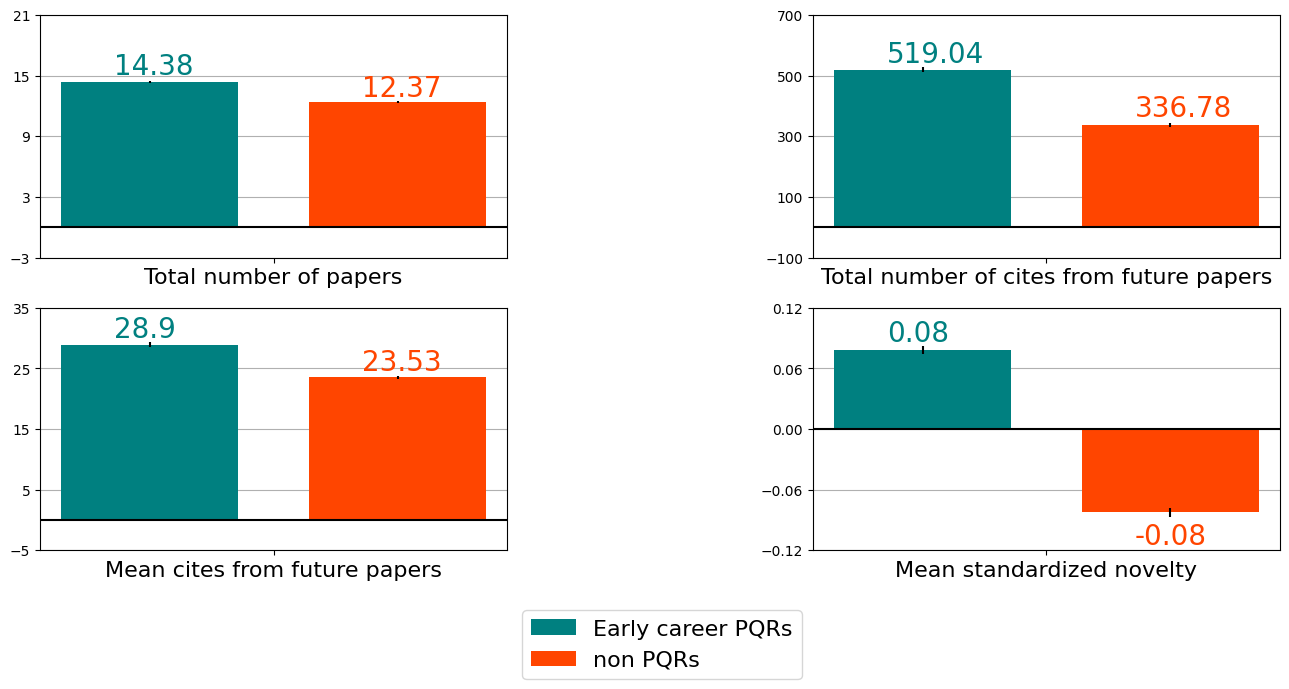

In [25]:
## plot the mean

import numpy as np 
import matplotlib.pyplot as plt 
import mpl_axes_aligner

fig,axes  = plt.subplots(2, 2, figsize=(13,7))

# set width of bar 
barWidth = 0.05

# Set position of bar on X axis 
br1 = np.arange(1) 
br2 = [x + 0.02 + barWidth for x in br1] 

(ax1 , ax2), (ax3, ax4) = axes
axes = [ ax1,ax2,ax3,ax4 ] 


# set height of bar 
authors_PQRs = [mean_papers_PQRs , mean_cites_PQRs,mean_mean_cites_PQRs,mean_novelty_PQRs] 
authors_non_PQRs = [ mean_papers_non_PQRs, mean_cites_non_PQRs,mean_mean_cites_non_PQRs,mean_novelty_non_PQRs]

# set height of bar 
sem_authors_PQRs = [sem_papers_PQRs , sem_cites_PQRs,sem_mean_cites_PQRs,sem_novelty_PQRs] 
sem_authors_non_PQRs = [ sem_papers_non_PQRs, sem_cites_non_PQRs,sem_mean_cites_non_PQRs,sem_novelty_non_PQRs] 


i = 0 
labels = [ 'Total number of papers', 'Total number of cites from future papers', 'Mean cites from future papers', 'Mean standardized novelty' ] 
val = [ (0.7,0.6),(25,28) , (1.2,1.2), (0.0085,-0.032) ] 
height = [ (-3, 21 ) , (-100, 700 ) ,  (-5,35 ), (-0.10, 0.15) ] 
height = [ (-3,21 ) , (-100, 700 ) ,  (-5,35 ), (-0.12, 0.12) ] 



for i in range(4):

    ax = axes[i]

    # Adding Xticks 
    #ax1.set_title('Average number of papers published 20 years out', fontweight ='bold', fontsize = 18) 
    
    #ax.set_ylabel(labels[i])
    ax.bar(br1, authors_PQRs[i], color ='teal', width = barWidth, yerr = sem_authors_PQRs[i],
             label ='Early career PQRs') 
    ax.bar(br2, authors_non_PQRs[i], color ='orangered', width = barWidth, yerr = sem_authors_non_PQRs[i],
             label ='non PQRs')

    ax.axhline(0, color='k')
    ax.set_xticks([r + ( barWidth + 0.02)/2  for r in range(1)], [ labels[i] ]  , fontsize = 16)
    ax.set_axisbelow(True)
    ax.grid(axis='y')
    #ax.legend( bbox_to_anchor=(0.85, -0.1), ncols = 2)

    if i < 3:
        ax.text(br1[0] - 0.01 , authors_PQRs[i] + val[i][0]  ,  round(authors_PQRs[i],2) , color = 'teal', fontsize = 20)
        ax.text(br2[0] - 0.01, authors_non_PQRs[i] + val[i][1],  round(authors_non_PQRs[i],2) , color = 'orangered', fontsize = 20)
    else:
        ax.text(br1[0] - 0.01 , authors_PQRs[i] + val[i][0]  ,  round(authors_PQRs[i],2) , color = 'teal', fontsize = 20)
        ax.text(br2[0] - 0.01, authors_non_PQRs[i] + val[i][1],  round(authors_non_PQRs[i],2) , color = 'orangered', fontsize = 20)

    ax.set_yticks(np.linspace(height[i][0],height[i][1],5))

    if i == 3:
        ax.legend( bbox_to_anchor=(0, -0.2), ncols = 1, fontsize = 16)


fig.tight_layout()  # otherwise the right y-label is slightly clipped


plt.show() 
